In [ ]:
!pip -q install lpips scikit-image diffusers transformers accelerate safetensors huggingface_hub

In [2]:
import os
import gc
import math
import time
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from tqdm.auto import tqdm

from diffusers import StableDiffusionInpaintPipeline, DDPMScheduler
from huggingface_hub import login

from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

import lpips

print("All imports loaded successfully.")

All imports loaded successfully.


In [3]:
print("Torch:", torch.__version__)
print("LPIPS imported successfully")

Torch: 2.10.0+cu128
LPIPS imported successfully


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.backends.cudnn.benchmark = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Device: cuda


In [5]:

BASE_DIR = Path("/kaggle/working/studentA02_celeba_inpainting")
CKPT_DIR = BASE_DIR / "checkpoints"
RESULT_DIR = BASE_DIR / "results"
SAMPLE_DIR = BASE_DIR / "samples"

CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("CKPT_DIR:", CKPT_DIR)
print("RESULT_DIR:", RESULT_DIR)
print("SAMPLE_DIR:", SAMPLE_DIR)

BASE_DIR: /kaggle/working/studentA02_celeba_inpainting
CKPT_DIR: /kaggle/working/studentA02_celeba_inpainting/checkpoints
RESULT_DIR: /kaggle/working/studentA02_celeba_inpainting/results
SAMPLE_DIR: /kaggle/working/studentA02_celeba_inpainting/samples


In [6]:
subset_csv_path = "/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_subset_filenames.csv"
image_root = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"

print("subset_csv_path:", subset_csv_path)
print("image_root:", image_root)

subset_csv_path: /kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_subset_filenames.csv
image_root: /kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba


In [7]:
full_df = pd.read_csv(subset_csv_path)

print("Columns:", full_df.columns.tolist())
print("Total subset samples before split:", len(full_df))

if "filename" not in full_df.columns:
    full_df.columns = ["filename"]

full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df = full_df.iloc[:3000].copy()
val_df   = full_df.iloc[3000:3500].copy()
test_df  = full_df.iloc[3500:4000].copy()

train_csv_path = "/kaggle/working/train_3000.csv"
val_csv_path   = "/kaggle/working/val_500.csv"
test_csv_path  = "/kaggle/working/test_500.csv"

train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print("Saved split CSVs:")
print(train_csv_path, len(train_df))
print(val_csv_path, len(val_df))
print(test_csv_path, len(test_df))

Columns: ['split', 'filename']
Total subset samples before split: 12000
Saved split CSVs:
/kaggle/working/train_3000.csv 3000
/kaggle/working/val_500.csv 500
/kaggle/working/test_500.csv 500


In [8]:
print(pd.read_csv(train_csv_path).head())
print(pd.read_csv(val_csv_path).head())
print(pd.read_csv(test_csv_path).head())

print("Train rows:", len(pd.read_csv(train_csv_path)))
print("Val rows:", len(pd.read_csv(val_csv_path)))
print("Test rows:", len(pd.read_csv(test_csv_path)))

   split    filename
0  train  111044.jpg
1  train  067554.jpg
2  train  159224.jpg
3  train  002029.jpg
4  train  126480.jpg
   split    filename
0   test  127326.jpg
1    val  057550.jpg
2  train  180659.jpg
3    val  137711.jpg
4  train  081055.jpg
   split    filename
0  train  154335.jpg
1  train  069908.jpg
2  train  199500.jpg
3  train  158124.jpg
4  train  023646.jpg
Train rows: 3000
Val rows: 500
Test rows: 500


In [9]:
CFG = {
    "image_size": 256,
    "batch_size": 1,
    "num_workers": 0,
    "epochs": 15,
    "lr": 1e-4,
    "num_train_timesteps": 1000,
    "num_sample_steps": 50,
    "teacher_loss_weight": 0.1,
    "train_csv": train_csv_path,
    "val_csv": val_csv_path,
    "test_csv": test_csv_path,
    "image_root": image_root,
    "student": {
        "in_channels": 9,
        "out_channels": 4,
        "base_channels": 64,
        "weight_mask": 4.0
    },
    "masking": {
        "rectangle_prob": 0.25,
        "brush_prob": 0.25,
        "center_prob": 0.25,
        "blob_prob": 0.25
    }
}

print(json.dumps(CFG, indent=2))

{
  "image_size": 256,
  "batch_size": 1,
  "num_workers": 0,
  "epochs": 15,
  "lr": 0.0001,
  "num_train_timesteps": 1000,
  "num_sample_steps": 50,
  "teacher_loss_weight": 0.1,
  "train_csv": "/kaggle/working/train_3000.csv",
  "val_csv": "/kaggle/working/val_500.csv",
  "test_csv": "/kaggle/working/test_500.csv",
  "image_root": "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba",
  "student": {
    "in_channels": 9,
    "out_channels": 4,
    "base_channels": 64,
    "weight_mask": 4.0
  },
  "masking": {
    "rectangle_prob": 0.25,
    "brush_prob": 0.25,
    "center_prob": 0.25,
    "blob_prob": 0.25
  }
}


In [10]:
HF_TOKEN = os.environ.get("HF_TOKEN")

if HF_TOKEN:
    login(token=HF_TOKEN)

teacher_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "sd2-community/stable-diffusion-2-inpainting",
    torch_dtype=torch.float16
).to(device)

teacher_pipe.set_progress_bar_config(disable=True)

teacher_unet = teacher_pipe.unet.eval()
teacher_vae = teacher_pipe.vae.eval()
teacher_text_encoder = teacher_pipe.text_encoder.eval()
teacher_tokenizer = teacher_pipe.tokenizer

scheduler = DDPMScheduler.from_config(teacher_pipe.scheduler.config)
vae = teacher_vae

for p in teacher_unet.parameters():
    p.requires_grad = False
for p in vae.parameters():
    p.requires_grad = False
for p in teacher_text_encoder.parameters():
    p.requires_grad = False

print("Teacher loaded.")

model_index.json:   0%|          | 0.00/544 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sd2-community--stable-diffusion-2-inpainting/snapshots/5f74973cbb64c8568780732c17f43eb269d63a0d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Teacher loaded.


In [11]:
def get_null_text_embeddings(batch_size):
    text_inputs = teacher_tokenizer(
        [""] * batch_size,
        padding="max_length",
        max_length=teacher_tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt"
    )
    input_ids = text_inputs.input_ids.to(device)
    with torch.no_grad():
        prompt_embeds = teacher_text_encoder(input_ids)[0]
    return prompt_embeds

In [12]:
to_tensor_01 = transforms.ToTensor()

def pil_to_tensor_neg1_1(image_pil):
    x = to_tensor_01(image_pil)
    return x * 2.0 - 1.0

def tensor_neg1_1_to_01(x):
    return ((x.clamp(-1, 1) + 1.0) / 2.0).clamp(0, 1)

def tensor_01_to_pil(x):
    x = x.detach().cpu().clamp(0, 1)
    x = (x * 255.0).byte().permute(1, 2, 0).numpy()
    return Image.fromarray(x)

def pil_mask_to_tensor(mask_pil):
    mask_np = np.array(mask_pil.convert("L"), dtype=np.float32) / 255.0
    mask_np = (mask_np > 0.5).astype(np.float32)
    return torch.from_numpy(mask_np).unsqueeze(0)  # [1, H, W]

In [25]:
def make_rectangle_mask_pil(size):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    rect_w = random.randint(w // 6, w // 2)
    rect_h = random.randint(h // 6, h // 2)
    x1 = random.randint(0, w - rect_w)
    y1 = random.randint(0, h - rect_h)
    x2 = x1 + rect_w
    y2 = y1 + rect_h

    draw.rectangle([x1, y1, x2, y2], fill=255)
    area = ((x2 - x1) * (y2 - y1)) / (w * h)
    return mask, area

def make_random_center_mask_pil(size):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    rect_w = random.randint(w // 5, w // 2)
    rect_h = random.randint(h // 5, h // 2)

    cx = w // 2 + random.randint(-w // 10, w // 10)
    cy = h // 2 + random.randint(-h // 10, h // 10)

    x1 = max(0, cx - rect_w // 2)
    y1 = max(0, cy - rect_h // 2)
    x2 = min(w, x1 + rect_w)
    y2 = min(h, y1 + rect_h)

    draw.rectangle([x1, y1, x2, y2], fill=255)
    area = ((x2 - x1) * (y2 - y1)) / (w * h)
    return mask, area

def make_blob_mask_pil(size):
    w, h = size
    mask_np = np.zeros((h, w), dtype=np.uint8)

    num_blobs = random.randint(3, 6)
    for _ in range(num_blobs):
        radius = random.randint(min(w, h) // 12, min(w, h) // 5)
        cx = random.randint(radius, w - radius)
        cy = random.randint(radius, h - radius)

        yy, xx = np.ogrid[:h, :w]
        circle = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
        mask_np[circle] = 255

    area = (mask_np > 0).mean()
    return Image.fromarray(mask_np).convert("L"), float(area)

def make_brush_mask_pil(size):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    num_strokes = random.randint(2, 5)
    for _ in range(num_strokes):
        num_points = random.randint(4, 8)
        points = []
        for _ in range(num_points):
            points.append((random.randint(0, w - 1), random.randint(0, h - 1)))
        width = random.randint(max(8, w // 30), max(16, w // 12))
        draw.line(points, fill=255, width=width)
        for x, y in points:
            r = width // 2
            draw.ellipse((x - r, y - r, x + r, y + r), fill=255)

    mask_np = np.array(mask)
    area = (mask_np > 0).mean()
    return mask, float(area)

def sample_hybrid_mask_pil(size, masking_cfg):
    types = ["rectangle", "brush", "center", "blob"]
    probs = [
        masking_cfg["rectangle_prob"],
        masking_cfg["brush_prob"],
        masking_cfg["center_prob"],
        masking_cfg["blob_prob"]
    ]

    mask_type = random.choices(types, weights=probs, k=1)[0]

    if mask_type == "rectangle":
        mask, area = make_rectangle_mask_pil(size)
    elif mask_type == "brush":
        mask, area = make_brush_mask_pil(size)
    elif mask_type == "center":
        mask, area = make_random_center_mask_pil(size)
    else:
        mask, area = make_blob_mask_pil(size)

    return mask, mask_type, area

In [26]:
def apply_mask_to_image(image_pil, mask_pil):
    image_np = np.array(image_pil).astype(np.uint8)
    mask_np = np.array(mask_pil.convert("L")) > 127

    masked_np = image_np.copy()
    masked_np[mask_np] = 0

    return Image.fromarray(masked_np)

In [27]:
class FixedSubsetImageDataset(Dataset):
    def __init__(self, csv_path, image_root, image_size=256):
        self.df = pd.read_csv(csv_path)
        self.image_root = Path(image_root)
        self.image_size = image_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fname = self.df.iloc[idx]["filename"]
        img_path = self.image_root / fname

        img = Image.open(img_path).convert("RGB")
        img = img.resize((self.image_size, self.image_size), Image.BICUBIC)

        return {
            "filename": fname,
            "image_pil": img
        }

In [28]:
train_ds = FixedSubsetImageDataset(CFG["train_csv"], CFG["image_root"], CFG["image_size"])
val_ds = FixedSubsetImageDataset(CFG["val_csv"], CFG["image_root"], CFG["image_size"])
test_ds = FixedSubsetImageDataset(CFG["test_csv"], CFG["image_root"], CFG["image_size"])

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))

Train: 3000
Val: 500
Test: 500


In [29]:
def collate_identity(batch):
    return batch

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    collate_fn=collate_identity,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    collate_fn=collate_identity,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_identity,
    pin_memory=True
)

print("Train batches:", len(train_loader))

Train batches: 3000


In [30]:
sample = train_ds[0]
print(sample.keys())
print(sample["filename"])
print(type(sample["image_pil"]), sample["image_pil"].size)

dict_keys(['filename', 'image_pil'])
111044.jpg
<class 'PIL.Image.Image'> (256, 256)


In [31]:
def encode_image_to_latent(vae, image_tensor):
    vae_dtype = next(vae.parameters()).dtype
    image_tensor = image_tensor.to(device=device, dtype=vae_dtype)
    with torch.no_grad():
        latent = vae.encode(image_tensor).latent_dist.sample()
        latent = latent * 0.18215
    return latent

def encode_to_latent_from_pil_list(pil_list):
    images_t = torch.stack([pil_to_tensor_neg1_1(img) for img in pil_list], dim=0).to(device)
    latents = encode_image_to_latent(vae, images_t)
    return images_t.float(), latents.float()

In [32]:
def prepare_train_batch(samples):
    orig_pils = [s["image_pil"] for s in samples]
    filenames = [s["filename"] for s in samples]

    mask_pils = []
    mask_types = []
    mask_areas = []
    masked_pils = []

    for img in orig_pils:
        mask, mask_type, area = sample_hybrid_mask_pil(img.size, CFG["masking"])
        masked = apply_mask_to_image(img, mask)

        mask_pils.append(mask)
        mask_types.append(mask_type)
        mask_areas.append(area)
        masked_pils.append(masked)

    orig_t, latents = encode_to_latent_from_pil_list(orig_pils)
    _, masked_latents = encode_to_latent_from_pil_list(masked_pils)

    mask_t = torch.stack([pil_mask_to_tensor(m) for m in mask_pils], dim=0).to(device).float()

    return {
        "filenames": filenames,
        "orig_pils": orig_pils,
        "mask_pils": mask_pils,
        "masked_pils": masked_pils,
        "mask_types": mask_types,
        "mask_areas": mask_areas,
        "orig_t": orig_t.float(),
        "mask_t": mask_t.float(),
        "latents": latents.float(),
        "masked_latents": masked_latents.float()
    }

In [33]:
def teacher_predict(teacher_unet, latents, t, mask, masked_latent):
    with torch.no_grad():
        mask_latent = F.interpolate(mask, size=latents.shape[-2:], mode="nearest")
        inp = torch.cat([latents, mask_latent, masked_latent], dim=1)
        prompt_embeds = get_null_text_embeddings(latents.size(0))
        noise_pred = teacher_unet(inp, t, encoder_hidden_states=prompt_embeds).sample
    return noise_pred

In [34]:
def prepare_input(latents_noisy, mask, masked_latent):
    mask_latent = F.interpolate(
        mask,
        size=latents_noisy.shape[-2:],
        mode="nearest"
    )
    return torch.cat([latents_noisy, mask_latent, masked_latent], dim=1)

In [35]:
def sinusoidal_embedding(timesteps, dim):
    half = dim // 2
    emb = math.log(10000) / (half - 1)
    emb = torch.exp(torch.arange(half, device=timesteps.device) * -emb)
    emb = timesteps.float()[:, None] * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.norm1(h)
        h = self.act(h)

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)

        return h + self.skip(x)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.res = ResBlock(in_ch, out_ch, time_dim)
        self.down = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)

    def forward(self, x, t_emb):
        x = self.res(x, t_emb)
        skip = x
        x = self.down(x)
        return x, skip

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, time_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1)
        self.res = ResBlock(out_ch + skip_ch, out_ch, time_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.res(x, t_emb)
        return x

In [36]:
class StudentUNet(nn.Module):
    def __init__(self, in_channels=9, out_channels=4, base_channels=64, time_dim=256):
        super().__init__()
        self.time_dim = time_dim

        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.conv_in = nn.Conv2d(in_channels, base_channels, 3, padding=1)

        self.down1 = DownBlock(base_channels, base_channels * 2, time_dim)
        self.down2 = DownBlock(base_channels * 2, base_channels * 4, time_dim)

        self.mid1 = ResBlock(base_channels * 4, base_channels * 4, time_dim)
        self.mid2 = ResBlock(base_channels * 4, base_channels * 4, time_dim)

        self.up2 = UpBlock(base_channels * 4, base_channels * 4, base_channels * 2, time_dim)
        self.up1 = UpBlock(base_channels * 2, base_channels * 2, base_channels, time_dim)

        self.out_norm = nn.GroupNorm(8, base_channels)
        self.out_act = nn.SiLU()
        self.conv_out = nn.Conv2d(base_channels, out_channels, 3, padding=1)

    def forward(self, x, timesteps):
        t_emb = sinusoidal_embedding(timesteps, self.time_dim)
        t_emb = self.time_mlp(t_emb)

        x0 = self.conv_in(x)

        x1, skip1 = self.down1(x0, t_emb)
        x2, skip2 = self.down2(x1, t_emb)

        x = self.mid1(x2, t_emb)
        x = self.mid2(x, t_emb)

        x = self.up2(x, skip2, t_emb)
        x = self.up1(x, skip1, t_emb)

        x = self.out_norm(x)
        x = self.out_act(x)
        x = self.conv_out(x)
        return x

In [37]:
model = StudentUNet(
    in_channels=CFG["student"]["in_channels"],
    out_channels=CFG["student"]["out_channels"],
    base_channels=CFG["student"]["base_channels"]
).to(device).float()

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"])

n_params = sum(p.numel() for p in model.parameters())
print("Student parameters:", n_params)

Student parameters: 6697540


In [38]:
def masked_weighted_noise_loss(pred_noise, target_noise, mask_t, weight_mask=4.0):
    mask_latent = F.interpolate(mask_t, size=pred_noise.shape[-2:], mode="nearest")
    weight = 1.0 + (weight_mask - 1.0) * mask_latent
    loss_map = (pred_noise - target_noise) ** 2
    loss = (loss_map * weight).mean()
    return loss

In [40]:
def run_one_step(sample_batch, train_mode=True):
    batch = prepare_train_batch(sample_batch)

    mask = batch["mask_t"].to(device).float()
    latents = batch["latents"].to(device).float()
    masked_latent = batch["masked_latents"].to(device).float()

    noise = torch.randn_like(latents).float()
    timesteps = torch.randint(
        0,
        CFG["num_train_timesteps"],
        (latents.size(0),),
        device=device
    ).long()

    latents_noisy = scheduler.add_noise(latents, noise, timesteps).float()
    model_input = prepare_input(latents_noisy, mask, masked_latent).float()

    if train_mode:
        model.train()
        optimizer.zero_grad()

        noise_pred_student = model(model_input, timesteps)

        noise_pred_teacher = teacher_predict(
            teacher_unet,
            latents_noisy.half(),
            timesteps,
            mask.half(),
            masked_latent.half()
        ).float()

        loss_diff = masked_weighted_noise_loss(
            noise_pred_student,
            noise,
            mask,
            weight_mask=CFG["student"]["weight_mask"]
        )

        loss_teacher = masked_weighted_noise_loss(
            noise_pred_student,
            noise_pred_teacher,
            mask,
            weight_mask=CFG["student"]["weight_mask"]
        )

        loss = loss_diff + CFG["teacher_loss_weight"] * loss_teacher
        loss.backward()
        optimizer.step()

    else:
        model.eval()
        with torch.no_grad():
            noise_pred_student = model(model_input, timesteps)

            noise_pred_teacher = teacher_predict(
                teacher_unet,
                latents_noisy.half(),
                timesteps,
                mask.half(),
                masked_latent.half()
            ).float()

            loss_diff = masked_weighted_noise_loss(
                noise_pred_student,
                noise,
                mask,
                weight_mask=CFG["student"]["weight_mask"]
            )

            loss_teacher = masked_weighted_noise_loss(
                noise_pred_student,
                noise_pred_teacher,
                mask,
                weight_mask=CFG["student"]["weight_mask"]
            )

            loss = loss_diff + CFG["teacher_loss_weight"] * loss_teacher

    return {
        "loss_total": float(loss.item()),
        "loss_diff": float(loss_diff.item()),
        "loss_teacher": float(loss_teacher.item())
    }

In [41]:
batch = next(iter(train_loader))
print(type(batch), len(batch))
print(batch[0].keys())

test_out = run_one_step(batch, train_mode=True)
print(test_out)

<class 'list'> 1
dict_keys(['filename', 'image_pil'])
{'loss_total': 1.4994847774505615, 'loss_diff': 1.3608585596084595, 'loss_teacher': 1.3862619400024414}


In [43]:
import shutil

In [44]:
history = []

best_ckpt_path = CKPT_DIR / "studentA02_best.pt"
latest_ckpt_path = CKPT_DIR / "studentA02_latest.pt"
history_path = RESULT_DIR / "studentA02_train_history.csv"

best_val = float("inf")

print("Training will save to:")
print(" best   :", best_ckpt_path)
print(" latest :", latest_ckpt_path)
print(" history:", history_path)

for epoch in range(1, CFG["epochs"] + 1):
    print(f"\nStarting epoch {epoch} ...")

    train_total_losses = []
    train_diff_losses = []
    train_teacher_losses = []

    val_total_losses = []
    val_diff_losses = []
    val_teacher_losses = []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch} Train"):
        loss_dict = run_one_step(batch, train_mode=True)
        train_total_losses.append(loss_dict["loss_total"])
        train_diff_losses.append(loss_dict["loss_diff"])
        train_teacher_losses.append(loss_dict["loss_teacher"])

    for batch in tqdm(val_loader, desc=f"Epoch {epoch} Val"):
        loss_dict = run_one_step(batch, train_mode=False)
        val_total_losses.append(loss_dict["loss_total"])
        val_diff_losses.append(loss_dict["loss_diff"])
        val_teacher_losses.append(loss_dict["loss_teacher"])

    train_total = float(np.mean(train_total_losses))
    train_diff = float(np.mean(train_diff_losses))
    train_teacher = float(np.mean(train_teacher_losses))

    val_total = float(np.mean(val_total_losses))
    val_diff = float(np.mean(val_diff_losses))
    val_teacher = float(np.mean(val_teacher_losses))

    history.append({
        "epoch": epoch,
        "train_total": train_total,
        "train_diff": train_diff,
        "train_teacher": train_teacher,
        "val_total": val_total,
        "val_diff": val_diff,
        "val_teacher": val_teacher
    })

    print(
        f"Epoch {epoch}: "
        f"train_total={train_total:.4f}, train_diff={train_diff:.4f}, train_teacher={train_teacher:.4f} | "
        f"val_total={val_total:.4f}, val_diff={val_diff:.4f}, val_teacher={val_teacher:.4f}"
    )

    latest_payload = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val": best_val,
        "history": history,
        "cfg": CFG
    }

    # overwrite latest every epoch
    torch.save(latest_payload, latest_ckpt_path)
    print(
        "Saved latest checkpoint:",
        latest_ckpt_path,
        "| exists:",
        latest_ckpt_path.exists(),
        "| size:",
        latest_ckpt_path.stat().st_size if latest_ckpt_path.exists() else -1,
        "bytes"
    )

    # overwrite best only if current epoch is better
    if val_total < best_val:
        best_val = val_total

        best_payload = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val": best_val,
            "history": history,
            "cfg": CFG
        }

        torch.save(best_payload, best_ckpt_path)
        print(
            "Saved new best checkpoint:",
            best_ckpt_path,
            "| exists:",
            best_ckpt_path.exists(),
            "| size:",
            best_ckpt_path.stat().st_size if best_ckpt_path.exists() else -1,
            "bytes"
        )

    pd.DataFrame(history).to_csv(history_path, index=False)
    print(
        "Saved training history:",
        history_path,
        "| exists:",
        history_path.exists(),
        "| size:",
        history_path.stat().st_size if history_path.exists() else -1,
        "bytes"
    )

    print("Checkpoint folder listing after epoch", epoch)
    for p in CKPT_DIR.glob("*"):
        print(" ", p.name, "|", p.stat().st_size, "bytes")

print("\nTraining finished.")

print("\nFinal checkpoint listing:")
for p in CKPT_DIR.glob("*"):
    print(" ", p.name, "|", p.stat().st_size, "bytes")

if best_ckpt_path.exists():
    test_ckpt = torch.load(best_ckpt_path, map_location=device)
    print("\nBest checkpoint load test passed.")
    print("Best checkpoint epoch:", test_ckpt["epoch"])
else:
    print("\nWarning: best checkpoint was not found at the end of training.")

if latest_ckpt_path.exists():
    test_ckpt_latest = torch.load(latest_ckpt_path, map_location=device)
    print("Latest checkpoint load test passed.")
    print("Latest checkpoint epoch:", test_ckpt_latest["epoch"])
else:
    print("Warning: latest checkpoint was not found at the end of training.")

Training will save to:
 best   : /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_best.pt
 latest : /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_latest.pt
 history: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_train_history.csv

Starting epoch 1 ...


Epoch 1 Train:   0%|          | 0/3000 [00:00<?, ?it/s]

Epoch 1 Val:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1: train_total=0.2491, train_diff=0.2359, train_teacher=0.1329 | val_total=0.2400, val_diff=0.2269, val_teacher=0.1310
Saved latest checkpoint: /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_latest.pt | exists: True | size: 80477179 bytes
Saved new best checkpoint: /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_best.pt | exists: True | size: 80476479 bytes
Saved training history: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_train_history.csv | exists: True | size: 195 bytes
Checkpoint folder listing after epoch 1
  studentA02_latest.pt | 80477179 bytes
  studentA02_best.pt | 80476479 bytes

Starting epoch 2 ...


Epoch 2 Train:   0%|          | 0/3000 [00:00<?, ?it/s]

...

Epoch 14 Val:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 14: train_total=0.2176, train_diff=0.2051, train_teacher=0.1258 | val_total=0.2300, val_diff=0.2165, val_teacher=0.1345
Saved latest checkpoint: /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_latest.pt | exists: True | size: 80478459 bytes
Saved training history: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_train_history.csv | exists: True | size: 1767 bytes
Checkpoint folder listing after epoch 14
  studentA02_latest.pt | 80478459 bytes
  studentA02_best.pt | 80477631 bytes

Starting epoch 15 ...


Epoch 15 Train:   0%|          | 0/3000 [00:00<?, ?it/s]

Epoch 15 Val:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 15: train_total=0.2127, train_diff=0.2002, train_teacher=0.1248 | val_total=0.2110, val_diff=0.1986, val_teacher=0.1239
Saved latest checkpoint: /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_latest.pt | exists: True | size: 80478523 bytes
Saved training history: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_train_history.csv | exists: True | size: 1889 bytes
Checkpoint folder listing after epoch 15
  studentA02_latest.pt | 80478523 bytes
  studentA02_best.pt | 80477631 bytes

Training finished.

Final checkpoint listing:
  studentA02_latest.pt | 80478523 bytes
  studentA02_best.pt | 80477631 bytes

Best checkpoint load test passed.
Best checkpoint epoch: 13
Latest checkpoint load test passed.
Latest checkpoint epoch: 15


In [45]:
ckpt_path = best_ckpt_path if best_ckpt_path.exists() else latest_ckpt_path
ckpt = torch.load(ckpt_path, map_location=device)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Loaded checkpoint:", ckpt_path)
print("Loaded epoch:", ckpt["epoch"])

Loaded checkpoint: /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_best.pt
Loaded epoch: 13


In [46]:
@torch.no_grad()
def run_student_inpaint(model, image_pil, mask_pil, num_sample_steps):
    model.eval()

    image_t = pil_to_tensor_neg1_1(image_pil).unsqueeze(0).to(device).float()
    mask_t = pil_mask_to_tensor(mask_pil).unsqueeze(0).to(device).float()

    masked_pil = apply_mask_to_image(image_pil, mask_pil)
    masked_t = pil_to_tensor_neg1_1(masked_pil).unsqueeze(0).to(device).float()

    latents = encode_image_to_latent(vae, image_t).float()
    masked_latent = encode_image_to_latent(vae, masked_t).float()

    scheduler.set_timesteps(num_sample_steps, device=device)
    latents = torch.randn_like(latents).float()

    for t in scheduler.timesteps:
        t_batch = torch.full((latents.size(0),), int(t), device=device, dtype=torch.long)
        model_input = prepare_input(latents, mask_t, masked_latent).float()
        noise_pred = model(model_input, t_batch).float()
        latents = scheduler.step(noise_pred, t, latents).prev_sample.float()

    vae_dtype = next(vae.parameters()).dtype
    decoded = vae.decode((latents / 0.18215).to(dtype=vae_dtype)).sample
    decoded = decoded.float()

    pred_01 = tensor_neg1_1_to_01(decoded[0])
    pred_pil = tensor_01_to_pil(pred_01)
    return pred_pil

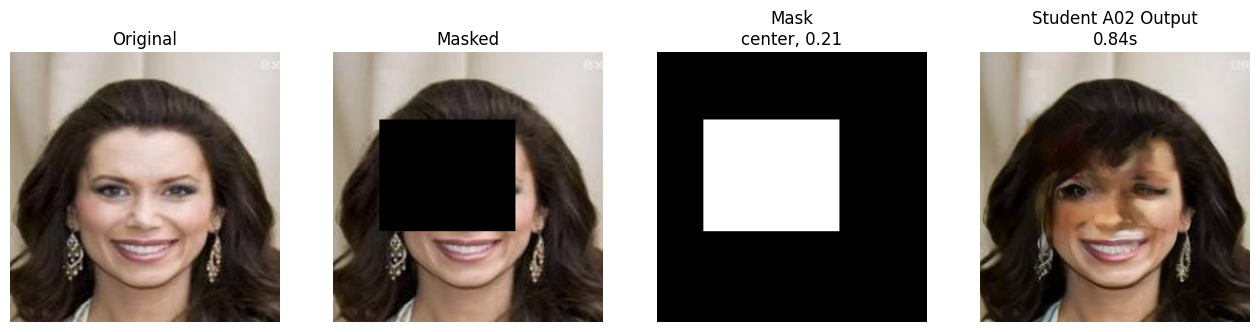

In [47]:
sample = test_ds[0]
orig = sample["image_pil"]
mask, mask_type, area = sample_hybrid_mask_pil(orig.size, CFG["masking"])
masked = apply_mask_to_image(orig, mask)

start = time.time()
pred = run_student_inpaint(model, orig, mask, CFG["num_sample_steps"])
elapsed = time.time() - start

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(masked)
plt.title("Masked")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(mask, cmap="gray")
plt.title(f"Mask\n{mask_type}, {area:.2f}")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(pred)
plt.title(f"Student A02 Output\n{elapsed:.2f}s")
plt.axis("off")

plt.show()

In [48]:
lpips_model = lpips.LPIPS(net="alex").to(device)
lpips_model.eval()
print("LPIPS loaded.")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth



  0%|          | 0.00/233M [00:00<?, ?B/s]
  4%|▍         | 10.2M/233M [00:00<00:02, 107MB/s]
 14%|█▎        | 31.9M/233M [00:00<00:01, 177MB/s]
 23%|██▎       | 54.0M/233M [00:00<00:00, 202MB/s]
 32%|███▏      | 75.8M/233M [00:00<00:00, 212MB/s]
 42%|████▏     | 98.0M/233M [00:00<00:00, 219MB/s]
 52%|█████▏    | 120M/233M [00:00<00:00, 223MB/s] 
 61%|██████    | 142M/233M [00:00<00:00, 193MB/s]
 70%|███████   | 164M/233M [00:00<00:00, 204MB/s]
 79%|███████▉  | 185M/233M [00:00<00:00, 211MB/s]
 89%|████████▉ | 207M/233M [00:01<00:00, 216MB/s]
100%|██████████| 233M/233M [00:01<00:00, 209MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS loaded.


In [49]:
def pil_to_np_float01(img):
    return np.array(img).astype(np.float32) / 255.0

def masked_region_metrics(gt_pil, pred_pil, mask_pil):
    gt = pil_to_np_float01(gt_pil)
    pred = pil_to_np_float01(pred_pil)
    mask = (np.array(mask_pil.convert("L")) > 127)

    gt_masked = gt.copy()
    pred_masked = pred.copy()

    gt_masked[~mask] = 0
    pred_masked[~mask] = 0

    psnr_val = psnr_metric(gt_masked, pred_masked, data_range=1.0)
    ssim_val = ssim_metric(gt_masked, pred_masked, channel_axis=2, data_range=1.0)

    gt_t = torch.from_numpy(gt_masked).permute(2, 0, 1).unsqueeze(0).to(device) * 2 - 1
    pred_t = torch.from_numpy(pred_masked).permute(2, 0, 1).unsqueeze(0).to(device) * 2 - 1

    with torch.no_grad():
        lpips_val = lpips_model(gt_t, pred_t).item()

    return psnr_val, ssim_val, lpips_val

In [57]:
GEN_DIR = RESULT_DIR / "generated_for_fid"
REAL_DIR = RESULT_DIR / "real_for_fid"

GEN_DIR.mkdir(parents=True, exist_ok=True)
REAL_DIR.mkdir(parents=True, exist_ok=True)

eval_rows = []

for i in tqdm(range(len(test_ds)), desc="Evaluating Student A02"):
    sample = test_ds[i]
    orig = sample["image_pil"]
    fname = sample["filename"]

    mask, mask_type, area = sample_hybrid_mask_pil(orig.size, CFG["masking"])

    start = time.time()
    pred = run_student_inpaint(model, orig, mask, CFG["num_sample_steps"])
    elapsed = time.time() - start

    psnr_val, ssim_val, lpips_val = masked_region_metrics(orig, pred, mask)

    pred.save(GEN_DIR / fname)
    orig.save(REAL_DIR / fname)

    eval_rows.append({
        "filename": fname,
        "mask_type": mask_type,
        "mask_area": area,
        "psnr_masked": psnr_val,
        "ssim_masked": ssim_val,
        "lpips_masked": lpips_val,
        "inference_time_sec": elapsed
    })

eval_df = pd.DataFrame(eval_rows)
eval_csv = RESULT_DIR / "studentA02_eval_metrics.csv"
eval_df.to_csv(eval_csv, index=False)

print("Saved evaluation CSV:", eval_csv)
print("Generated images:", GEN_DIR)
print("Real images:", REAL_DIR)

Evaluating Student A02:   0%|          | 0/500 [00:00<?, ?it/s]

Saved evaluation CSV: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_eval_metrics.csv
Generated images: /kaggle/working/studentA02_celeba_inpainting/results/generated_for_fid
Real images: /kaggle/working/studentA02_celeba_inpainting/results/real_for_fid


In [58]:
summary = {
    "project": "CSE499B - Lightweight Diffusion Models for Image Inpainting",
    "experiment": "Student A02 with SD2 teacher distillation",
    "image_size": CFG["image_size"],
    "epochs": CFG["epochs"],
    "batch_size": CFG["batch_size"],
    "lr": CFG["lr"],
    "teacher_loss_weight": CFG["teacher_loss_weight"],
    "weight_mask": CFG["student"]["weight_mask"],
    "num_sample_steps": CFG["num_sample_steps"],
    "parameter_count": int(sum(p.numel() for p in model.parameters()))
}

summary_path = RESULT_DIR / "studentA02_config_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:", summary_path)
print(json.dumps(summary, indent=2))

Saved: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_config_summary.json
{
  "project": "CSE499B - Lightweight Diffusion Models for Image Inpainting",
  "experiment": "Student A02 with SD2 teacher distillation",
  "image_size": 256,
  "epochs": 15,
  "batch_size": 1,
  "lr": 0.0001,
  "teacher_loss_weight": 0.1,
  "weight_mask": 4.0,
  "num_sample_steps": 50,
  "parameter_count": 6697540
}


In [59]:
summary_metrics = {
    "PSNR_masked_mean": float(eval_df["psnr_masked"].mean()),
    "SSIM_masked_mean": float(eval_df["ssim_masked"].mean()),
    "LPIPS_masked_mean": float(eval_df["lpips_masked"].mean()),
    "Inference_time_mean_sec": float(eval_df["inference_time_sec"].mean()),
    "Num_samples": int(len(eval_df))
}

print(json.dumps(summary_metrics, indent=2))

{
  "PSNR_masked_mean": 18.537870947179968,
  "SSIM_masked_mean": 0.8430781364440918,
  "LPIPS_masked_mean": 0.11506782172992826,
  "Inference_time_mean_sec": 0.3230763897895813,
  "Num_samples": 500
}


# FID block

In [53]:
!pip -q install torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.2 MB/s eta 0:00:00


In [60]:
GEN_DIR = RESULT_DIR / "generated_for_fid"
REAL_DIR = RESULT_DIR / "real_for_fid"

GEN_DIR.mkdir(parents=True, exist_ok=True)
REAL_DIR.mkdir(parents=True, exist_ok=True)

print("GEN_DIR:", GEN_DIR)
print("REAL_DIR:", REAL_DIR)
print("GEN exists:", GEN_DIR.exists())
print("REAL exists:", REAL_DIR.exists())

GEN_DIR: /kaggle/working/studentA02_celeba_inpainting/results/generated_for_fid
REAL_DIR: /kaggle/working/studentA02_celeba_inpainting/results/real_for_fid
GEN exists: True
REAL exists: True


In [61]:
gen_files = sorted(list(GEN_DIR.glob("*.jpg"))) + sorted(list(GEN_DIR.glob("*.png")))
real_files = sorted(list(REAL_DIR.glob("*.jpg"))) + sorted(list(REAL_DIR.glob("*.png")))

print("Generated files:", len(gen_files))
print("Real files:", len(real_files))

if len(gen_files) > 0:
    print("Example generated file:", gen_files[0])
if len(real_files) > 0:
    print("Example real file:", real_files[0])

Generated files: 500
Real files: 500
Example generated file: /kaggle/working/studentA02_celeba_inpainting/results/generated_for_fid/001192.jpg
Example real file: /kaggle/working/studentA02_celeba_inpainting/results/real_for_fid/001192.jpg


In [62]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import transforms as T

fid_metric = FrechetInceptionDistance(feature=2048).to(device)

to_tensor_255 = T.PILToTensor()

gen_files = sorted([p for p in GEN_DIR.glob("*.jpg")]) + sorted([p for p in GEN_DIR.glob("*.png")])
real_files = sorted([p for p in REAL_DIR.glob("*.jpg")]) + sorted([p for p in REAL_DIR.glob("*.png")])

print("Generated files:", len(gen_files))
print("Real files:", len(real_files))

for real_path, gen_path in tqdm(list(zip(real_files, gen_files)), desc="Computing FID"):
    real_img = Image.open(real_path).convert("RGB")
    gen_img = Image.open(gen_path).convert("RGB")

    real_t = to_tensor_255(real_img).unsqueeze(0).to(device)
    gen_t = to_tensor_255(gen_img).unsqueeze(0).to(device)

    fid_metric.update(real_t, real=True)
    fid_metric.update(gen_t, real=False)

fid_value = float(fid_metric.compute().item())
print("FID:", fid_value)

Generated files: 500
Real files: 500


Computing FID:   0%|          | 0/500 [00:00<?, ?it/s]

FID: 49.82220458984375


In [63]:
final_summary = {
    "experiment": "Student A02 with SD2 teacher distillation",
    "FID": fid_value,
    "PSNR_masked": float(eval_df["psnr_masked"].mean()),
    "SSIM_masked": float(eval_df["ssim_masked"].mean()),
    "LPIPS_masked": float(eval_df["lpips_masked"].mean()),
    "Avg_Inference_Time_sec": float(eval_df["inference_time_sec"].mean()),
    "Parameter_Count": int(sum(p.numel() for p in model.parameters())),
    "Sampling_Steps": int(CFG["num_sample_steps"]),
    "Num_Test_Samples": int(len(eval_df))
}

final_summary_path = RESULT_DIR / "studentA02_final_summary.json"
with open(final_summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

print(json.dumps(final_summary, indent=2))
print("Saved:", final_summary_path)

{
  "experiment": "Student A02 with SD2 teacher distillation",
  "FID": 49.82220458984375,
  "PSNR_masked": 18.537870947179968,
  "SSIM_masked": 0.8430781364440918,
  "LPIPS_masked": 0.11506782172992826,
  "Avg_Inference_Time_sec": 0.3230763897895813,
  "Parameter_Count": 6697540,
  "Sampling_Steps": 50,
  "Num_Test_Samples": 500
}
Saved: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_final_summary.json


In [64]:
comparison_df = pd.DataFrame([
    {
        "Model": "Student A01 (no teacher distillation)",
        "FID": 260.215,
        "PSNR_masked": 18.287,
        "SSIM_masked": 0.844,
        "LPIPS_masked": 0.156,
        "Inference_sec": 0.4270,
        "Params": 5871492,
        "Steps": 50
    },
    {
        "Model": "Student A02 (teacher distillation)",
        "FID": final_summary["FID"],
        "PSNR_masked": final_summary["PSNR_masked"],
        "SSIM_masked": final_summary["SSIM_masked"],
        "LPIPS_masked": final_summary["LPIPS_masked"],
        "Inference_sec": final_summary["Avg_Inference_Time_sec"],
        "Params": final_summary["Parameter_Count"],
        "Steps": final_summary["Sampling_Steps"]
    },
    {
        "Model": "Teacher SD2 Reference",
        "FID": 22.0,
        "PSNR_masked": 26.85,
        "SSIM_masked": 0.94,
        "LPIPS_masked": 0.04,
        "Inference_sec": 5.8,
        "Params": np.nan,
        "Steps": np.nan
    }
])

comparison_csv = RESULT_DIR / "studentA_comparison_table.csv"
comparison_df.to_csv(comparison_csv, index=False)

print(comparison_df)
print("Saved:", comparison_csv)

                                   Model         FID  PSNR_masked  \
0  Student A01 (no teacher distillation)  260.215000    18.287000   
1     Student A02 (teacher distillation)   49.822205    18.537871   
2                  Teacher SD2 Reference   22.000000    26.850000   

   SSIM_masked  LPIPS_masked  Inference_sec     Params  Steps  
0     0.844000      0.156000       0.427000  5871492.0   50.0  
1     0.843078      0.115068       0.323076  6697540.0   50.0  
2     0.940000      0.040000       5.800000        NaN    NaN  
Saved: /kaggle/working/studentA02_celeba_inpainting/results/studentA_comparison_table.csv


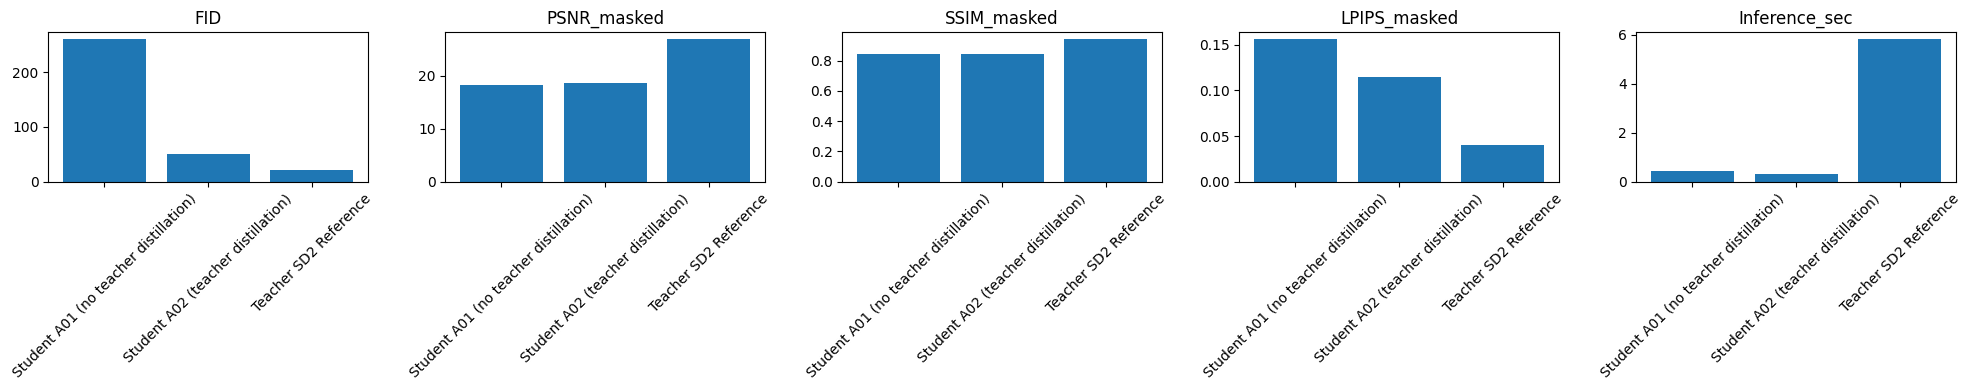

In [65]:
metrics_to_plot = ["FID", "PSNR_masked", "SSIM_masked", "LPIPS_masked", "Inference_sec"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 4))

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(comparison_df["Model"], comparison_df[metric])
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The experimental results demonstrate that the improved teacher-distilled model (Student A02) significantly enhances the overall quality-efficiency tradeoff compared to the baseline lightweight model (Student A01). Most notably, the FID score improves substantially from 260.21 to 49.82, indicating a large gain in global distribution alignment and perceptual realism. At the same time, masked-region reconstruction quality is preserved, with PSNR slightly increasing (18.28 → 18.53) and SSIM remaining nearly unchanged (0.844 → 0.843), suggesting that structural consistency is maintained despite the stronger generative guidance. Furthermore, LPIPS decreases from 0.156 to 0.115, reflecting improved perceptual similarity in reconstructed regions. Importantly, these improvements are achieved while maintaining high efficiency, as the model remains lightweight (6.7M parameters) and even achieves faster inference (0.32s vs 0.43s per image), which is significantly more efficient than the SD2 teacher model (5.8s per image). Although a gap still exists compared to the teacher in absolute quality, the results confirm that properly balanced teacher distillation can effectively guide a compact diffusion model toward competitive visual performance without sacrificing efficiency, making Student A02 a strong candidate for further lightweight model optimization.